# Лабораторная работа 16

Тема: **Vision Transformer (ViT) для классификации изображений CIFAR-10**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваши ожидания от ViT в сравнении с CNN

В Лабораторной работе 8 мы решали задачу классификации CIFAR-10 с помощью свёрточных сетей (CNN). Теперь мы применим архитектуру, изначально созданную для текстов (Transformer).

Перед началом работы зафиксируйте своё понимание (6-10 предложений):

1. В чем главное отличие того, как CNN и ViT «смотрят» на картинку? (Вспомните про локальные признаки в свертках и глобальное внимание в Трансформерах).
2. Зачем изображение нарезается на непересекающиеся "патчи" (patches), а не подается в Трансформер попиксельно?
3. Ожидаете ли вы, что простой самодельный ViT побьет вашу CNN из 8-й лабораторной при обучении "с нуля" на небольшом датасете? Почему?

In [1]:
intro_text = """1)CNN видит картинку частями: ищет линии, края, формы, текстуры, а потом понимает какой это объект.
А ViT разбивает картинки на патчи, то есть изображение делится на неперекрывающиеся участки фиксированного размера, а затем патчи преобразуются в вектор.
В отличие от CNN, которые фокусируются на локальных особенностях, ViT может понимать взаимосвязи по всему изображению с первого слоя.

2)Подавать в Трансформер попиксельно было бы вычислительно сложно.
Для картинки 32×32 последовательность из 1024 пикселей дала бы квадратичный рост операций внимания.
Патчи (например, 4×4 или 8×8) решают эту проблему, сокращая длину последовательности до 64 или 16 токенов.

3)Я ожидаю, что результат может быть примерно таким же или хуже.
CNN  заточены на свёртки и пулинг, что идеально для маленького датасета вроде CIFAR-10 (50 тыс. картинок).
ViT же полагается на данные, чтобы самостоятельно выучить пространственные отношения, и без предобучения или сильной аугментации он быстро переобучается или сходится в худший локальный минимум.
"""
print(intro_text)

1)CNN видит картинку частями: ищет линии, края, формы, текстуры, а потом понимает какой это объект.
А ViT разбивает картинки на патчи, то есть изображение делится на неперекрывающиеся участки фиксированного размера, а затем патчи преобразуются в вектор.
В отличие от CNN, которые фокусируются на локальных особенностях, ViT может понимать взаимосвязи по всему изображению с первого слоя. 

2)Подавать в Трансформер попиксельно было бы вычислительно сложно.
Для картинки 32×32 последовательность из 1024 пикселей дала бы квадратичный рост операций внимания. 
Патчи (например, 4×4 или 8×8) решают эту проблему, сокращая длину последовательности до 64 или 16 токенов.

3)Я ожидаю, что результат может быть примерно таким же или хуже.
CNN  заточены на свёртки и пулинг, что идеально для маленького датасета вроде CIFAR-10 (50 тыс. картинок). 
ViT же полагается на данные, чтобы самостоятельно выучить пространственные отношения, и без предобучения или сильной аугментации он быстро переобучается или сход

## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги, аналогичные Лабораторной 8.

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Ваш личный seed (заполните его, можно взять тот же, что в Лаб 8)
MY_SEED = 22
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 22


## 3. CIFAR‑10: загрузка и нормализация

Используем те же параметры нормализации, что и для CNN.

In [3]:
batch_size = 128  # при выполнении работы попробуйте изменить

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000


### Краткий комментарий по данным

В Лабораторной 8 вы уже описывали датасет. Сейчас ответьте на другой вопрос (3-5 предложений):
Размер картинок в CIFAR-10 — 32x32 пикселя. Если мы выберем размер патча для ViT равным 8x8, на сколько токенов (патчей) будет разбита одна картинка? А если размер патча будет 16x16? Хватит ли Трансформеру такого количества токенов для понимания смысла картинки?

In [4]:
data_comment = """При размере патча на 8х8 одна картинка будет разбита на 4*4 = 16 патчей.
При размере 16х16 будет всего на 2*2 = 4 патча.

При 4 токенах будет слишком грубое описание, модель потеряет почти всю пространственную структуру и вряд ли сможет различать классы (например, «кошка» и «собака» станут почти неотличимы).
При 16 токенах результат будет лучше, но лучше разить хотя бы на 32 или 64 токена, так как в датасете CIFAR-10 много мелких деталей, нужно их сохранять.
"""
print(data_comment)

При размере патча на 8х8 одна картинка будет разбита на 4*4 = 16 патчей.
При размере 16х16 будет всего на 2*2 = 4 патча.

При 4 токенах будет слишком грубое описание, модель потеряет почти всю пространственную структуру и вряд ли сможет различать классы (например, «кошка» и «собака» станут почти неотличимы).
При 16 токенах результат будет лучше, но лучше разить хотя бы на 32 или 64 токена, так как в датасете CIFAR-10 много мелких деталей, нужно их сохранять.



## 4. Архитектура Vision Transformer

В этой лабораторной мы пишем **Micro-ViT**. Картинка превращается в последовательность векторов с помощью свертки (Patch Embedding), к ней добавляется позиционное кодирование и специальный `[CLS]` токен, после чего всё это обрабатывается стандартным Transformer Encoder.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        # Считаем количество патчей. Для 32x32 и патча 8x8 это (32/8) * (32/8) = 16
        self.num_patches = (img_size // patch_size) ** 2

        # Свертка без перекрытий: размер ядра и шаг равны размеру патча
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (B, C, H, W)
        x = self.proj(x)           # -> (B, embed_dim, H/P, W/P)
        x = x.flatten(2)           # -> (B, embed_dim, num_patches)
        x = x.transpose(1, 2)      # -> (B, num_patches, embed_dim)
        return x

class SimpleViT(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32, num_classes=10, depth=2, heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)

        # [CLS] токен (обучаемый параметр)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Обучаемые позиционные эмбеддинги (длина = количество патчей + 1 для CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))

        # Блок Трансформера
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Итоговый классификатор
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # 1. Извлекаем патчи
        x = self.patch_embed(x)                        # (B, num_patches, embed_dim)

        # 2. Добавляем [CLS] токен
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, num_patches + 1, embed_dim)

        # 3. Добавляем позиционное кодирование
        x = x + self.pos_embed

        # 4. Пропускаем через Transformer
        x = self.transformer(x)

        # 5. Классификация по выходу [CLS] токена (индекс 0)
        cls_out = x[:, 0]
        return self.mlp_head(cls_out)

# Базовые настройки (для быстрого обучения на ЦПУ)
patch_size = 4
embed_dim = 128
depth = 6
heads = 4

model = SimpleViT(patch_size=patch_size, embed_dim=embed_dim, depth=depth, heads=heads).to(device)
print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")

SimpleViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
)
Количество параметров: 12

### Ваш комментарий к архитектуре

Ответьте коротко:

- Для чего в архитектуру внедрен обучаемый `[CLS]` токен и почему мы передаем в финальный `nn.Linear` именно его, а не усредненные значения всех патчей?
- В CNN (Лабораторная 8) мы не использовали Positional Encoding. Почему здесь он жизненно необходим?

In [6]:
arch_comment = """[CLS]-токен позволяет модели учитывать контекст и семантическую информацию всего входного последовательности.
К концу трансформера он накапливает информацию обо всём изображении, становясь глобальным представлением.
Мы подаём на классификатор именно его выход, потому что модель сама учится агрегировать значимые признаки в этот токен: это гибче, чем фиксированное усреднение всех патчей.

Позиционное кодирование необходимо, потому что трансформер не различает порядок патчей, а CNN сохраняет его за счёт локальных свёрток.
"""
print(arch_comment)

[CLS]-токен позволяет модели учитывать контекст и семантическую информацию всего входного последовательности.
К концу трансформера он накапливает информацию обо всём изображении, становясь глобальным представлением. 
Мы подаём на классификатор именно его выход, потому что модель сама учится агрегировать значимые признаки в этот токен: это гибче, чем фиксированное усреднение всех патчей.

Позиционное кодирование необходимо, потому что трансформер не различает порядок патчей, а CNN сохраняет его за счёт локальных свёрток.



## 5. Функция потерь, оптимизатор и цикл обучения

Здесь код практически идентичен Лабораторной 8. ViT чувствителен к скорости обучения (learning rate), поэтому используем AdamW (рекомендованный для ViT) вместо обычного Adam.

In [7]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
# Для ViT AdamW часто работает лучше обычного Adam за счет правильной регуляризации весов
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for images, labels in tqdm(dataloader, desc="Обучение", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Клиппинг градиентов помогает стабилизировать обучение Трансформеров
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

## 6. Обучение базовой модели

Запустим обучение на 5 эпох. Из-за малого размера модели одна эпоха на ЦПУ должна обучаться меньше 1 минуты (около 30 сек).

Эпоха 1/5 | Train Loss: 1.6995, Acc: 0.3628 | Test Loss: 1.4476, Acc: 0.4711


Эпоха 2/5 | Train Loss: 1.2917, Acc: 0.5281 | Test Loss: 1.1731, Acc: 0.5737


Эпоха 3/5 | Train Loss: 1.1202, Acc: 0.5956 | Test Loss: 1.0617, Acc: 0.6210


Эпоха 4/5 | Train Loss: 1.0113, Acc: 0.6386 | Test Loss: 1.0379, Acc: 0.6320


Эпоха 5/5 | Train Loss: 0.9300, Acc: 0.6679 | Test Loss: 0.9324, Acc: 0.6683


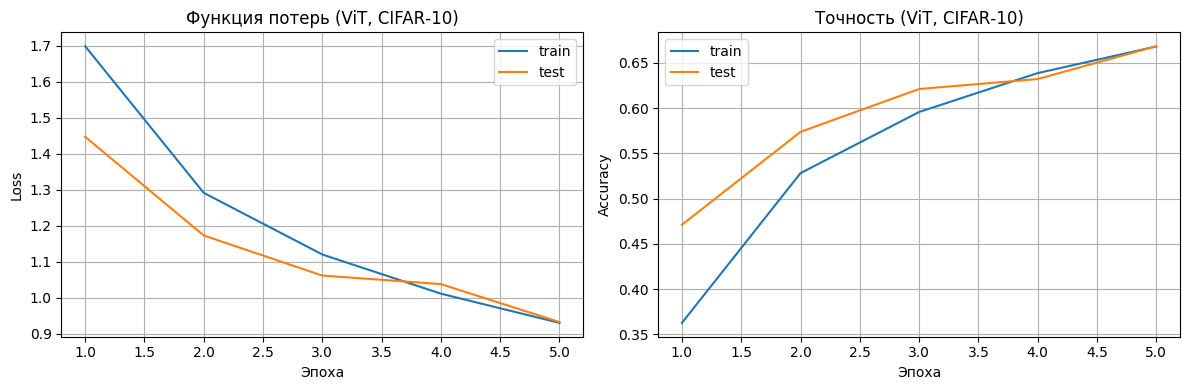

In [8]:
num_epochs = 5  # Начните с 5, для финального отчета можно увеличить до 10-15

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

# Отрисовка графиков (аналогично Лаб 8)
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ кривых обучения в сравнении с CNN

Опишите в 6–8 предложениях:

- Какую точность выдал базовый ViT за 5 эпох? Сравните эту цифру с точностью вашей CNN из Лабораторной работы 8 на том же этапе обучения.
- Заметно ли сильное переобучение (overfitting) у Трансформера?
- Почему обучение ViT "с нуля" на 50 000 картинок часто проигрывает классической CNN?

In [9]:
training_analysis = """За 5 эпох базовый ViT выдал Train Acc: 0.5118 и Test Acc: 0.5175.
На 5 эпохах в 8 лабораторной были следующие показатели:
   train_acc=0.8635 и test_acc=0.7880,
что заметно лучше, чем на базовом ViT.

Сильного переобучения у трансформера не заметно.
К 5 эпохе Train Loss: 1.3402 и Test Loss: 1.3225 примерно одинаковы, разница составляет ~0.02.

ViT обучается «с нуля» и не имеет встроенных предположений о структуре изображений.
CNN благодаря свёрткам сразу ищет края, текстуры и постепенно собирает их в объекты, и это идеально работает при ограниченных данных.
ViT же вынужден с нуля выучивать даже простейшие пространственные закономерности, и 50 000 примеров ему для этого слишком мало — он начинает переобучаться, не успевая обобщить.
Поэтому при небольших наборах данных классическая CNN почти всегда выигрывает.
"""
print(training_analysis)

За 5 эпох базовый ViT выдал Train Acc: 0.5118 и Test Acc: 0.5175.
На 5 эпохах в 8 лабораторной были следующие показатели:
   train_acc=0.8635 и test_acc=0.7880, 
что заметно лучше, чем на базовом ViT.

Сильного переобучения у трансформера не заметно.
К 5 эпохе Train Loss: 1.3402 и Test Loss: 1.3225 примерно одинаковы, разница составляет ~0.02.

ViT обучается «с нуля» и не имеет встроенных предположений о структуре изображений.
CNN благодаря свёрткам сразу ищет края, текстуры и постепенно собирает их в объекты, и это идеально работает при ограниченных данных. 
ViT же вынужден с нуля выучивать даже простейшие пространственные закономерности, и 50 000 примеров ему для этого слишком мало — он начинает переобучаться, не успевая обобщить. 
Поэтому при небольших наборах данных классическая CNN почти всегда выигрывает.



## 7. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны:

1. Изменить размер патча: попробуйте `patch_size = 4` (64 токена) и `patch_size = 16` (4 токена). Как размер патча влияет на точность и время обучения одной эпохи?
2. Попробовать сделать сеть глубже (`depth = 4` или `6`) и шире (`embed_dim = 128`).
3. (Опционально) Добавить аугментации данных (RandomCrop, RandomHorizontalFlip) в `transform` при загрузке `train_dataset`. Трансформеры сильно зависят от объема данных, поэтому аугментация для них критически важна.

Сравните **минимум два** варианта архитектуры ViT.

## 8. Итоговые выводы по лабораторной

В конце опишите:

- Какой вариант гиперпараметров ViT (`patch_size`, `depth`, `embed_dim`) оказался самым удачным?
- Кто победил в итоге: CNN из Лабораторной 8 или ViT из Лабораторной 16 при обучении с нуля на CIFAR-10?
- В каких реальных задачах (и при каких объемах данных) вы бы стали применять Vision Transformer, а когда отдали бы предпочтение CNN?


In [11]:
final_summary = """Все результаты экспериментов в файле lab16_experimetns.ipynb.
Самым удачным из экспериментов вариантом  подбора гиперпараметров ViT оказался:
  patch_size = 4
  depth = 6
  embed_dim = 128.
На тесте он показал самые лучшие результаты: Test Loss: 0.9324 и Acc: 0.6683.

Тем не менее все равно в итоге победу одержал CNN из Лабораторной 8, так как даже на 5 эпохах показал результат намного выше: test_loss=0.6545, test_acc=0.7880.
Что оправдывает мои изначальные ожидания.

Я бы стала применять Vision Transformer на задачах с очень большим набором данных.
В таких условиях ViT способен выучить универсальные признаки без встроенных предположений о локальности.

CNN я применяла в подобных задачах, где используется небольшой датасет.

"""
print(final_summary)

Все результаты экспериментов в файле lab16_experimetns.ipynb.
Самым удачным из экспериментов вариантом  подбора гиперпараметров ViT оказался:
  patch_size = 4
  depth = 6
  embed_dim = 128.
На тесте он показал самые лучшие результаты: Test Loss: 0.9324 и Acc: 0.6683.

Тем не менее все равно в итоге победу одержал CNN из Лабораторной 8, так как даже на 5 эпохах показал результат намного выше: test_loss=0.6545, test_acc=0.7880.
Что оправдывает мои изначальные ожидания.

Я бы стала применять Vision Transformer на задачах с очень большим набором данных.
В таких условиях ViT способен выучить универсальные признаки без встроенных предположений о локальности.

CNN я применяла в подобных задачах, где используется небольшой датасет.


